In [12]:
"""
Multiphase Wind Evolution - Multicloud Version

This module extends the single-cloud wind evolution model to handle multiple cloud species
with a power-law mass distribution: dN/dM ∝ M^-α

Based on Fielding & Bryan "The Structure of Multiphase Galactic Winds"
"""

import numpy as np
import glob
from scipy import integrate, interpolate
import matplotlib
import matplotlib.pyplot as plt
import h5py

# plt.style.use('dark_background')

matplotlib.rcParams['xtick.direction'] = 'in'
matplotlib.rcParams['ytick.direction'] = 'in'
matplotlib.rcParams['xtick.top'] = True
matplotlib.rcParams['ytick.right'] = True
matplotlib.rcParams['xtick.minor.visible'] = True
matplotlib.rcParams['ytick.minor.visible'] = True
matplotlib.rcParams['lines.dash_capstyle'] = "round"
matplotlib.rcParams['lines.solid_capstyle'] = "round"
matplotlib.rcParams['legend.handletextpad'] = 0.4
matplotlib.rcParams['axes.linewidth'] = 0.6
matplotlib.rcParams['ytick.major.width'] = 0.6
matplotlib.rcParams['xtick.major.width'] = 0.6
matplotlib.rcParams['ytick.minor.width'] = 0.45
matplotlib.rcParams['xtick.minor.width'] = 0.45
matplotlib.rcParams['ytick.major.size'] = 2.75
matplotlib.rcParams['xtick.major.size'] = 2.75
matplotlib.rcParams['ytick.minor.size'] = 1.75
matplotlib.rcParams['xtick.minor.size'] = 1.75
matplotlib.rcParams['legend.handlelength'] = 2
matplotlib.rcParams["figure.dpi"] = 200


plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{cmbright}  \usepackage[T1]{fontenc}')

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors as colors
from matplotlib import cm
from matplotlib.colors import ListedColormap
from scipy.integrate import ode
from scipy.integrate import solve_ivp
from scipy import optimize
import cmasher as cmr
import matplotlib.font_manager
from matplotlib.lines import Line2D
import time

gamma   = 5/3.
kb      = 1.3806488e-16
mp      = 1.67373522381e-24
km      = 1e5
s       = 1
yr      = 3.1536e7
Myr     = 3.1536e13
Gyr     = 3.1536e16
pc      = 3.086e18
kpc     = 1.0e3 * pc
Mpc     = 1.0e6 * pc
H0   = 67.74*km/s/Mpc
Om   = 0.3075
OL = 1 - Om
G       = 6.673e-8
Msun    = 2.e33
fb      = 0.158
keV     = 1.60218e-9

mu = 0.62
metallicity = 10**-0.5
muH = 1/0.75
redshift = 0.5


"""
Cooling curve as a function of density, temperature, metallicity, redshift
"""
# First check if Lambda_tab_redshifts.npz exists in current directory
file = glob.glob('./Lambda_tab_redshifts.npz')
if len(file) == 0:
    # Check in the Tables directory
    file = glob.glob('/Users/dbf75/Work/Research/CCAResearch/Tables/Lambda_tab_redshifts.npz')
if len(file) > 0:
    data = np.load(file[0])
    Lambda_tab = data['Lambda_tab']
    redshifts  = data['redshifts']
    Zs         = data['Zs']
    log_Tbins  = data['log_Tbins']
    log_nHbins = data['log_nHbins']    
    Lambda     = interpolate.RegularGridInterpolator((log_nHbins,log_Tbins,Zs,redshifts), Lambda_tab, bounds_error=False, fill_value=1e-30)
else:
    print("Generating cooling table (this will take ~1 minute)...")
    start_time = time.time()
    
    files = np.sort(glob.glob('/Users/dbf75/Work/Research/CCAResearch/Tables/CoolingTables/z_*hdf5'))
    redshifts = np.array([float(f[-10:-5]) for f in files])
    HHeCooling = {}
    ZCooling   = {}
    TE_T_n     = {}
    # Define metallicity grid
    Zs = np.logspace(-3, 0.3, 15)  # Metallicity from 0.001 to 2 solar
    
    print(f"Processing {len(files)} HDF5 files...")
    for i in range(len(files)):
        if i % 10 == 0:
            print(f"  File {i+1}/{len(files)}...")
        f            = h5py.File(files[i], 'r')
        i_X_He       = -3 
        Metal_free   = f.get('Metal_free')
        Total_Metals = f.get('Total_Metals')
        log_Tbins    = np.array(np.log10(Metal_free['Temperature_bins']))
        log_nHbins   = np.array(np.log10(Metal_free['Hydrogen_density_bins']))
        Cooling_Metal_free       = np.array(Metal_free['Net_Cooling'])[i_X_He]
        Cooling_Total_Metals     = np.array(Total_Metals['Net_cooling'])
        HHeCooling[redshifts[i]] = interpolate.RectBivariateSpline(log_Tbins,log_nHbins, Cooling_Metal_free)
        ZCooling[redshifts[i]]   = interpolate.RectBivariateSpline(log_Tbins,log_nHbins, Cooling_Total_Metals)
        f.close()
    
    # Build Lambda_tab efficiently
    print(f"Building 4D cooling table ({len(log_nHbins)}x{len(log_Tbins)}x{len(Zs)}x{len(redshifts)})...")
    Lambda_tab = np.zeros((len(log_nHbins), len(log_Tbins), len(Zs), len(redshifts)))
    
    for i_n, ln in enumerate(log_nHbins):
        if i_n % 20 == 0:
            print(f"  Density {i_n+1}/{len(log_nHbins)}...")
        for i_T, lT in enumerate(log_Tbins):
            for i_Z, Z in enumerate(Zs):
                for i_z, zz in enumerate(redshifts):
                    Lambda_tab[i_n, i_T, i_Z, i_z] = HHeCooling[zz].ev(lT, ln) + Z * ZCooling[zz].ev(lT, ln)
    
    np.savez('./Lambda_tab_redshifts.npz', Lambda_tab=Lambda_tab, redshifts=redshifts, Zs=Zs, log_Tbins=log_Tbins, log_nHbins=log_nHbins)
    Lambda      = interpolate.RegularGridInterpolator((log_nHbins,log_Tbins,Zs,redshifts), Lambda_tab, bounds_error=False, fill_value=0)
    
    elapsed = time.time() - start_time
    print(f"Cooling table generated in {elapsed:.1f} seconds")
print("interpolated lambda")


metallicity = 1.
redshift = 0.
Ps = np.logspace(-8,10,100)
rhos = np.logspace(-10,5,101)*mu*mp
Lambda_P_rho_tab = np.zeros((len(Ps),len(rhos)))
for i in range(len(Ps)):
    for j in range(len(rhos)):
        rho = rhos[j]
        T = Ps[i] * (mu*mp/rho)
        if rho > 1*muH*mp:
            rho = 1.*muH*mp
        elif rho < 1e-8*muH*mp:
            rho = 1e-8*muH*mp
        if T > 10**8.98:
            T = 10**8.98
        elif T < 1e2:
            T = 1e2
        try:
            Lambda_P_rho_tab[i,j] = Lambda((np.log10(rho/(muH*mp)),np.log10(T), metallicity, redshift))
        except:
            Lambda_P_rho_tab[i,j] = 1e-30
    if i%10 == 0:
        print(i)

Lambda_P_rho = interpolate.RegularGridInterpolator((Ps*kb, rhos), Lambda_P_rho_tab, bounds_error=False, fill_value=0.)


Lambda_z0  = interpolate.RegularGridInterpolator((log_nHbins,log_Tbins,Zs), Lambda_tab[...,0], bounds_error=False, fill_value=-1e-30)

def tcool_P(T, P, metallicity, redshift=0.0):
    T = np.where(T>10**8.98, 10**8.98, T)
    T = np.where(T<10**2, 10**2, T)
    nH_actual = P/T*(mu/muH)
    nH = np.where(nH_actual>1, 1, nH_actual)
    nH = np.where(nH<10**-8, 10**-8, nH)
    # Use Lambda interpolator with redshift (default z=0)
    lambda_val = Lambda((np.log10(nH), np.log10(T), metallicity, redshift))
    return 1.5 * (muH/mu) * kb * T / (nH_actual * lambda_val)

def Lambda_P(T, P, metallicity, redshift=0.0):
    nH = P/T*(mu/muH)
    if nH > 0.9:
        nH = 0.9
    return Lambda((np.log10(nH), np.log10(T), metallicity, redshift))
Lambda_P = np.vectorize(Lambda_P)


T = np.logspace(3.5,6.5,1000)
T_tcool_min_array = np.zeros((len(Ps),len(Zs)))
tcool_min_array = np.zeros((len(Ps),len(Zs)))
for i,P in enumerate(Ps):
    if P > 10**4.2:
        continue
    for j,Z in enumerate(Zs):
        tcools = tcool_P(T, P, Z)
        T_tcool_min_array[i,j] = T[np.where(tcools == np.min(tcools[np.where(tcools>0)]))[0][0]]
        tcool_min_array[i,j] = np.min(tcools[tcools>0])

for i in np.where(Ps > 10**4.2)[0]:
    T_tcool_min_array[i] = T_tcool_min_array[np.where(Ps > 10**4.2)[0][0]-1]
    tcool_min_array[i] = tcool_min_array[np.where(Ps > 10**4.2)[0][0]-1] * (Ps[i]/ Ps[np.where(Ps > 10**4.2)[0][0]-1])**-1

T_tcool_min_P  = interpolate.RegularGridInterpolator((Ps,Zs), T_tcool_min_array, bounds_error=False, fill_value=None )
tcool_min_P  = interpolate.RegularGridInterpolator((Ps,Zs), tcool_min_array, bounds_error=False, fill_value=None )


def Field_Length(state, f_spitzer=1):
    rho_wind     = state[1]
    Pressure     = state[2]
    rhoZ_wind    = state[3]
    Z_wind       = rhoZ_wind/rho_wind
    T_wind       = Pressure/kb/(rho_wind/(mu*mp))
    kappa        = 5.0e-7 * T_wind**2.5
    edot_cool    = 1.5*Pressure / tcool_min_P((Pressure/kb,Z_wind/Z_solar))   
    return np.sqrt(f_spitzer*kappa*T_wind / edot_cool)

def Field_Length_mix(state, f_spitzer=1):
    rho_wind     = state[1]
    Pressure     = state[2]
    rhoZ_wind    = state[3]
    Z_wind       = rhoZ_wind/rho_wind
    T_wind       = Pressure/kb/(rho_wind/(mu*mp))
    Z_cloud      = state[6]

    T_mix        = (T_wind*T_cloud)**0.5
    Z_mix        = (Z_wind*Z_cloud)**0.5
    t_cool_layer = tcool_P(T_mix, Pressure/kb, Z_mix/Z_solar)[()] 
    t_cool_layer = np.where(t_cool_layer<0, 1e10*Myr, t_cool_layer)
    kappa = 5.0e-7 * T_wind**2.5
    edot_cool = 1.5*Pressure / t_cool_layer   
    return np.sqrt(f_spitzer*kappa*T_wind / (edot_cool))

def setup_cloud_powerlaw_distribution(log_M_cloud_min, log_M_cloud_max, N_cloud_species, 
                                     alpha_cloud, eta_M_cold_tot, SFR):
    """
    Set up a power-law distribution of cloud masses: dN/dM ∝ M^-α
    
    Parameters:
    -----------
    log_M_cloud_min : float
        Log10 of minimum cloud mass in solar masses
    log_M_cloud_max : float
        Log10 of maximum cloud mass in solar masses
    N_cloud_species : int
        Number of cloud mass bins
    alpha_cloud : float
        Power-law exponent (default=2.0)
    eta_M_cold_tot : float
        Total cold phase mass loading factor
    SFR : float
        Star formation rate in Msun/yr
    
    Returns:
    --------
    M_cloud0 : array
        Initial cloud masses for each species (Msun)
    eta_M_cold : array
        Mass loading factor for each cloud species
    Mdot_cold0 : array
        Mass flux for each cloud species (Msun/yr)
    Ndot_cloud0 : array
        Number flux for each cloud species (1/yr)
    """
    # Generate logarithmically spaced cloud mass bin edges
    M_cloud0 = np.logspace(log_M_cloud_min, log_M_cloud_max, N_cloud_species) * Msun
    
    # Power-law distribution: dN/dM ∝ M^-α
    # For each bin, we need dN/dlogM ∝ M^(1-α)
    dN_dlogM = M_cloud0**(1 - alpha_cloud)
    
    # Width of each logarithmic bin
    dlogM = np.diff(np.log10(M_cloud0))[0]
    
    # Number of clouds in each bin (relative)
    N_rel = dN_dlogM * dlogM
    
    # Mass in each bin: M * dN
    M_in_bin = M_cloud0 * N_rel
    
    # Normalize to get eta_M_cold for each species
    eta_M_cold = eta_M_cold_tot * M_in_bin / np.sum(M_in_bin)
    
    # Mass flux for each species
    Mdot_cold0 = eta_M_cold * SFR
    
    # Number flux for each species
    Ndot_cloud0 = Mdot_cold0 / M_cloud0
    
    return M_cloud0, eta_M_cold, Mdot_cold0, Ndot_cloud0

def cloud_radius(r, state, N_cloud_species=1):
    v_wind       = state[0]
    rho_wind     = state[1]
    Pressure     = state[2]
    rhoZ_wind    = state[3]
    
    if N_cloud_species == 1:
        # Single cloud case for backward compatibility
        M_cloud      = state[4]
        v_cloud      = state[5]
        Z_cloud      = state[6]
    else:
        # Multicloud case
        M_cloud      = state[4:4+N_cloud_species]
        v_cloud      = state[4+N_cloud_species:4+2*N_cloud_species]
        Z_cloud      = state[-N_cloud_species:]
    
    rho_cloud    = Pressure * (mu*mp) / (kb*T_cloud) # cloud in pressure equilibrium
    chi          = rho_cloud / rho_wind
    r_cloud      = (M_cloud / ( 4*np.pi/3. * rho_cloud))**(1/3.) 
    return r_cloud

def cloud_ksi(r, state, N_cloud_species=1):
    v_wind       = state[0]
    rho_wind     = state[1]
    Pressure     = state[2]
    rhoZ_wind    = state[3]
    Z_wind       = rhoZ_wind/rho_wind
    
    if N_cloud_species == 1:
        # Single cloud case for backward compatibility
        M_cloud      = state[4]
        v_cloud      = state[5]
        Z_cloud      = state[6]
    else:
        # Multicloud case
        M_cloud      = state[4:4+N_cloud_species]
        v_cloud      = state[4+N_cloud_species:4+2*N_cloud_species]
        Z_cloud      = state[-N_cloud_species:]
        
    rho_cloud    = Pressure * (mu*mp) / (kb*T_cloud) # cloud in pressure equilibrium
    chi          = rho_cloud / rho_wind
    r_cloud      = (M_cloud / ( 4*np.pi/3. * rho_cloud))**(1/3.) 
    v_rel        = (v_wind-v_cloud)
    v_turb       = f_turb0 * v_rel * chi**TurbulentVelocityChiPower
    T_wind       = Pressure/kb * (mu*mp/rho_wind)
    T_mix        = (T_wind*T_cloud)**0.5
    
    # Handle Z_mix for arrays
    if N_cloud_species == 1:
        Z_mix = (Z_wind*Z_cloud)**0.5
        t_cool_layer = tcool_P(T_mix, Pressure/kb, Z_mix/Z_solar)[()] 
    else:
        # For multiple clouds, we need to handle each species
        t_cool_layer = np.zeros_like(Z_cloud)
        for i in range(N_cloud_species):
            Z_mix_i = (Z_wind*Z_cloud[i])**0.5
            t_cool_layer[i] = tcool_P(T_mix, Pressure/kb, Z_mix_i/Z_solar)[()] 
    
    t_cool_layer = np.where(t_cool_layer<0, 1e10*Myr, t_cool_layer)
    ksi          = r_cloud / (v_turb * t_cool_layer)
    return ksi




def Cooling_and_Acceleration(r, state):
    v_wind     = state[0]
    rho_wind   = state[1]
    Pressure   = state[2]
    rhoZ_wind  = state[3]
    M_cloud    = state[4]
    v_cloud    = state[5]
    Z_cloud    = state[6]

    # wind properties
    cs_sq_wind   = (gamma*Pressure/rho_wind)
    Mach_sq_wind = (v_wind**2 / cs_sq_wind)
    Z_wind       = rhoZ_wind/rho_wind
    vc           = v_circ0  # Simple isothermal potential
    Phir         = v_circ0**2 * np.log(r) 
    vBsq_wind    = 0.5 * v_wind**2 + (gamma / (gamma-1)) * Pressure/rho_wind + Phir

    # source term from inside galaxy
    Edot_SN = Edot_per_Vol * np.where(Mach_sq_wind<1, 1.0, 0.0) #* np.where(r<r0, 1.0, 0.0)
    Mdot_SN = Mdot_per_Vol * np.where(Mach_sq_wind<1, 1.0, 0.0) #* np.where(r<r0, 1.0, 0.0)

    # cloud properties
    Ndot_cloud              = Ndot_cloud0 * np.where(r<cold_cloud_injection_radial_extent, (r/cold_cloud_injection_radial_extent)**cold_cloud_injection_radial_power, 1.0)
    number_density_cloud    = Ndot_cloud/(Omwind * v_cloud * r**2)
    cs_cl_sq                = gamma * kb*T_cloud/(mu*mp)
    vBsq_cl                 = 0.5 * v_cloud**2 + (gamma / (gamma-1)) * cs_cl_sq + Phir

    # cloud transfer rates
    rho_cloud    = Pressure * (mu*mp) / (kb*T_cloud) # cloud in pressure equilibrium
    chi          = rho_cloud / rho_wind
    r_cloud      = (M_cloud / ( 4*np.pi/3. * rho_cloud))**(1/3.) 
    v_rel        = (v_wind-v_cloud)
    v_turb       = f_turb0 * v_rel * chi**TurbulentVelocityChiPower
    T_wind       = Pressure/kb * (mu*mp/rho_wind)
    T_mix        = (T_wind*T_cloud)**0.5
    Z_mix        = (Z_wind*Z_cloud)**0.5
    t_cool_layer = tcool_P(T_mix, Pressure/kb, Z_mix/Z_solar)[()] 
    t_cool_layer = np.where(t_cool_layer<0, 1e10*Myr, t_cool_layer)
    ksi          = r_cloud / (v_turb * t_cool_layer)
    AreaBoost    = geometric_factor * chi**CoolingAreaChiPower
    v_turb_cold  = v_turb * chi**ColdTurbulenceChiPower
    Mdot_grow    = Mdot_coefficient * 3.0 *  M_cloud * v_turb * AreaBoost / (r_cloud * chi) * np.where( ksi < 1, ksi**0.5, ksi**0.25 )
    Mdot_loss    = Mdot_coefficient * 3.0 * -M_cloud * v_turb_cold / r_cloud 
    Mdot_cloud   = np.where(M_cloud > M_cloud_min, Mdot_grow + Mdot_loss, 0)

    # density
    drhodt      = -1.0 * (number_density_cloud * Mdot_cloud)
    drhodt_plus     = -1.0 * (number_density_cloud * Mdot_loss)
    drhodt_minus    = -1.0 * (number_density_cloud * Mdot_grow) 

    # momentum
    p_dot_drag      = 0.5 * drag_coeff * rho_wind * np.pi * v_rel**2 * r_cloud**2 * np.where(M_cloud>M_cloud_min, 1, 0)
    p_dot_transfer  = v_wind*Mdot_grow + v_cloud*Mdot_loss
    dpdt            = -1.0 * (number_density_cloud * (p_dot_transfer + p_dot_drag))
    dpdt_p          = -1.0 * (number_density_cloud * v_cloud*Mdot_loss)
    dpdt_m          = -1.0 * (number_density_cloud * v_wind*Mdot_grow)
    dpdt_drag       = -1.0 * (number_density_cloud * p_dot_drag)
    
    # energy
    e_dot_cool        = 0.0 if (Cooling_Factor==0) else (rho_wind/(muH*mp))**2 * Lambda_P_rho((Pressure,rho_wind))
    e_dot_transfer    = vBsq_wind*Mdot_grow + vBsq_cl*Mdot_loss
    dedt              = -1.0 * (number_density_cloud * (e_dot_transfer + p_dot_drag*v_cloud)) - e_dot_cool
    dv_cloud_dr       = (p_dot_drag + v_rel*Mdot_grow - M_cloud * vc**2/r) / (M_cloud * v_cloud) * np.where(M_cloud>M_cloud_min, 1, 0)
    return number_density_cloud * e_dot_transfer, e_dot_cool, dv_cloud_dr


def Wind_Evo(r, state):
    """
    Compute wind evolution derivatives - multicloud version
    Matches the original multicloud.py formulation exactly
    
    State vector format:
    [v_wind, rho_wind, Pressure, rhoZ_wind, 
     M_cloud_1, ..., M_cloud_N,
     v_cloud_1, ..., v_cloud_N,
     Z_cloud_1, ..., Z_cloud_N]
    """
    
    # Determine N_cloud_species from state vector length
    # state has: 4 wind vars + 3*N_cloud_species cloud vars
    N_cloud_species = (len(state) - 4) // 3
    
    # Unpack state vector
    v_wind     = state[0]
    rho_wind   = state[1]
    Pressure   = state[2]
    rhoZ_wind  = state[3]
    M_cloud    = state[4:4+N_cloud_species]
    v_cloud    = state[4+N_cloud_species:4+2*N_cloud_species]
    Z_cloud    = state[-N_cloud_species:]
    
    # Ensure arrays for single cloud case
    if N_cloud_species == 1:
        M_cloud = np.atleast_1d(M_cloud)
        v_cloud = np.atleast_1d(v_cloud)
        Z_cloud = np.atleast_1d(Z_cloud)
    
    
    # Wind properties
    cs_sq_wind   = gamma * Pressure / rho_wind
    Mach_sq_wind = v_wind**2 / cs_sq_wind
    Z_wind       = rhoZ_wind / rho_wind
    vc           = v_circ0  # Simple isothermal potential
    Phir         = v_circ0**2 * np.log(r)
    vBsq_wind    = 0.5 * v_wind**2 + (gamma/(gamma-1)) * Pressure/rho_wind + Phir

    # Cloud properties with injection cutoff
    Ndot_cloud = Ndot_cloud0 * np.where(r < cold_cloud_injection_radial_extent, 
                                        (r/cold_cloud_injection_radial_extent)**cold_cloud_injection_radial_power, 
                                        1.0)

    number_density_cloud = Ndot_cloud / (Omwind * v_cloud * r**2)
    cs_cl_sq = gamma * kb * T_cloud / (mu * mp)
    vBsq_cl = 0.5 * v_cloud**2 + (gamma/(gamma-1)) * cs_cl_sq + Phir

    # Cloud transfer rates
    rho_cloud = Pressure * (mu*mp) / (kb*T_cloud)  # Pressure equilibrium
    chi = rho_cloud / rho_wind
    r_cloud = (M_cloud / (4*np.pi/3. * rho_cloud))**(1/3.)
    v_rel = v_wind - v_cloud
    v_turb = f_turb0 * v_rel * chi**TurbulentVelocityChiPower
    T_wind = Pressure/kb * (mu*mp/rho_wind)
    T_mix = np.sqrt(T_wind * T_cloud)
    Z_mix = np.sqrt(Z_wind * Z_cloud)
    
    # Cooling time with proper handling
    t_cool_layer = tcool_P(T_mix, Pressure/kb, Z_mix/Z_solar)
    if np.isscalar(t_cool_layer):
        t_cool_layer = np.full_like(M_cloud, t_cool_layer)
    t_cool_layer = np.where(t_cool_layer < 0, 1e10*Myr, t_cool_layer)
    
    ksi = r_cloud / (v_turb * t_cool_layer)
    AreaBoost = geometric_factor * chi**CoolingAreaChiPower
    v_turb_cold = v_turb * chi**ColdTurbulenceChiPower
    
    # Mass transfer rates (Mdot_loss is negative!)
    # Only calculate for clouds above minimum mass
    cloud_active = M_cloud > M_cloud_min
    Mdot_grow = np.where(cloud_active,
                        Mdot_coefficient * 3.0 * M_cloud * v_turb * AreaBoost / (r_cloud * chi) * np.where(ksi < 1, ksi**0.5, ksi**0.25),
                        0)
    Mdot_loss = np.where(cloud_active,
                        Mdot_coefficient * 3.0 * -M_cloud * v_turb_cold / r_cloud,
                        0)
    Mdot_cloud = Mdot_grow + Mdot_loss

    # Density source
    drhodt = -1.0 * np.sum(number_density_cloud * Mdot_cloud)
    
    # Momentum source
    p_dot_ram = 0.5 * drag_coeff * rho_wind * np.pi * v_rel**2 * r_cloud**2
    p_dot_transfer = v_wind*Mdot_grow + v_cloud*Mdot_loss
    dpdt = -1.0 * np.sum(number_density_cloud * (p_dot_transfer + p_dot_ram))
    
    # Energy source
    e_dot_cool = 0.0 if (Cooling_Factor == 0) else -(rho_wind/(muH*mp))**2 * Lambda_P_rho((Pressure, rho_wind))
    e_dot_transfer = vBsq_wind*Mdot_grow + vBsq_cl*Mdot_loss
    dedt = -1.0 * np.sum(number_density_cloud * (e_dot_transfer + p_dot_ram*v_wind)) + e_dot_cool
    
    # Metallicity source
    drhoZdt = -1.0 * np.sum(number_density_cloud * (Z_wind*Mdot_grow + Z_cloud*Mdot_loss))

    # wind gradients
    dv_dr    = (v_wind/r)/(1.0-(1.0/Mach_sq_wind)) * ( 2.0/Mach_sq_wind - (vc/v_wind)**2 
                - 1/(rho_wind*v_wind/r) * (drhodt*(gamma+1)/2. - gamma * dpdt/v_wind + (gamma-1)*dedt/v_wind**2 - (gamma-1) * (Phir/v_wind**2)*drhodt)) 
    drho_dr  = (rho_wind/r)/(1.0-(1.0/Mach_sq_wind)) * ( -2.0 + (vc/v_wind)**2 
                + 1/(rho_wind*v_wind/r) * (drhodt*(gamma+3)/2. - gamma * dpdt/v_wind + (gamma-1)*dedt/v_wind**2 - drhodt/Mach_sq_wind + (gamma-1) * (Phir/v_wind**2)*drhodt)) 
    drhoZ_dr = ((rhoZ_wind/r)/(1.0-(1.0/Mach_sq_wind)) * ( -2.0 + (vc/v_wind)**2 
                + 1/(rho_wind*v_wind/r) * (drhodt*(gamma+3)/2. - gamma * dpdt/v_wind + (gamma-1)*dedt/v_wind**2 - drhodt/Mach_sq_wind + (gamma-1) * (Phir/v_wind**2)*drhodt))
                + (rhoZ_wind/r)*(1/(rho_wind*v_wind/r))*((drhoZdt/Z_wind)-drhodt))
    dP_dr    = (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind)) * ( -2.0 + (vc/v_wind)**2 
                + 1/(rho_wind*v_wind/r) * (drhodt + drhodt * (gamma-1)/2.*Mach_sq_wind * (1 - 2.0 * Phir/v_wind**2) - dpdt/v_wind + (gamma-1)*Mach_sq_wind*(dedt-v_wind*dpdt)/v_wind**2))

    # Cloud gradients - set all to 0 for clouds below minimum mass
    dM_cloud_dr = np.where(cloud_active, Mdot_cloud / v_cloud, 0)
    
    dv_cloud_dr = np.where(cloud_active,
                          (p_dot_ram + v_rel*Mdot_grow - M_cloud * vc**2/r) / (M_cloud * v_cloud),
                          0)
    
    dZ_cloud_dr = np.where(cloud_active, 
                          (Z_wind - Z_cloud) * Mdot_grow / (M_cloud * v_cloud),
                          0)

    # Return derivatives
    if N_cloud_species == 1:
        return np.r_[dv_dr, drho_dr, dP_dr, drhoZ_dr, dM_cloud_dr[0], dv_cloud_dr[0], dZ_cloud_dr[0]]
    else:
        return np.concatenate([
            [dv_dr, drho_dr, dP_dr, drhoZ_dr],
            dM_cloud_dr,
            dv_cloud_dr,
            dZ_cloud_dr
        ])

def Gradient_Components(r, state):
    v_wind     = state[0]
    rho_wind   = state[1]
    Pressure   = state[2]
    rhoZ_wind  = state[3]
    M_cloud    = state[4]
    v_cloud    = state[5]
    Z_cloud    = state[6]

    # wind properties
    cs_sq_wind   = (gamma*Pressure/rho_wind)
    Mach_sq_wind = (v_wind**2 / cs_sq_wind)
    Z_wind       = rhoZ_wind/rho_wind
    vc           = v_circ0  # Simple isothermal potential
    Phir         = v_circ0**2 * np.log(r) 
    # vc           = v_circ0 * np.where(r<r0, (r/r0)**2, 1.0)
    # Phir         = v_circ0**2 * np.where(r<r0, (1/3.) * (r/r0)**3, np.log(r)) 
    vBsq_wind    = 0.5 * v_wind**2 + (gamma / (gamma-1)) * Pressure/rho_wind + Phir

    # source term from inside galaxy
    Edot_SN = Edot_per_Vol * np.where(Mach_sq_wind<1, 1.0, 0.0) #* np.where(r<r0, 1.0, 0.0)
    Mdot_SN = Mdot_per_Vol * np.where(Mach_sq_wind<1, 1.0, 0.0) #* np.where(r<r0, 1.0, 0.0)

    # cloud properties
    Ndot_cloud              = Ndot_cloud0 * np.where(r<cold_cloud_injection_radial_extent, (r/cold_cloud_injection_radial_extent)**cold_cloud_injection_radial_power, 1.0)
    number_density_cloud    = Ndot_cloud/(Omwind * v_cloud * r**2)
    cs_cl_sq                = gamma * kb*T_cloud/(mu*mp)
    vBsq_cl                 = 0.5 * v_cloud**2 + (gamma / (gamma-1)) * cs_cl_sq + Phir

    # cloud transfer rates
    rho_cloud    = Pressure * (mu*mp) / (kb*T_cloud) # cloud in pressure equilibrium
    chi          = rho_cloud / rho_wind
    r_cloud      = (M_cloud / ( 4*np.pi/3. * rho_cloud))**(1/3.) 
    v_rel        = (v_wind-v_cloud)
    v_turb       = f_turb0 * v_rel * chi**TurbulentVelocityChiPower
    T_wind       = Pressure/kb * (mu*mp/rho_wind)
    T_mix        = (T_wind*T_cloud)**0.5
    Z_mix        = (Z_wind*Z_cloud)**0.5
    t_cool_layer = tcool_P(T_mix, Pressure/kb, Z_mix/Z_solar)[()] 
    t_cool_layer = np.where(t_cool_layer<0, 1e10*Myr, t_cool_layer)
    ksi          = r_cloud / (v_turb * t_cool_layer)
    AreaBoost    = geometric_factor * chi**CoolingAreaChiPower
    v_turb_cold  = v_turb * chi**ColdTurbulenceChiPower
    Mdot_grow    = Mdot_coefficient * 3.0 * M_cloud * v_turb * AreaBoost / (r_cloud * chi) * np.where( ksi < 1, ksi**0.5, ksi**0.25 )
    Mdot_loss    = Mdot_coefficient * 3.0 * -M_cloud * v_turb_cold / r_cloud 
    Mdot_cloud   = np.where(M_cloud > M_cloud_min, Mdot_grow + Mdot_loss, 0)

    # density
    drhodt       = -1.0 * (number_density_cloud * Mdot_cloud)  # Net change (negative)
    drhodt_plus  = (number_density_cloud * (-Mdot_loss))       # Mass added to wind (positive)
    drhodt_minus = (number_density_cloud * Mdot_grow)          # Mass removed from wind (positive) 

    # momentum
    p_dot_drag   = 0.5 * drag_coeff * rho_wind * np.pi * v_rel**2 * r_cloud**2 * np.where(M_cloud>M_cloud_min, 1, 0)
    dpdt_drag    = (number_density_cloud * p_dot_drag)
    
    # energy
    e_dot_cool   = 0.0 if (Cooling_Factor==0) else (rho_wind/(muH*mp))**2 * Lambda_P_rho((Pressure,rho_wind))

    # metallicity
    drhoZdt         = -1.0 * (number_density_cloud * (Z_wind*Mdot_grow + Z_cloud*Mdot_loss))

    # wind gradients
    # velocity
    dv_dr       = 2/Mach_sq_wind
    dv_dr      += - (vc/v_wind)**2
    dv_dr      +=  drhodt_minus/(rho_wind*v_wind/r) *  (1/Mach_sq_wind)
    dv_dr      += -drhodt_plus/(rho_wind*v_wind/r) * (1/Mach_sq_wind)
    dv_dr      += -drhodt_plus/(rho_wind*v_wind/r) * v_rel/v_wind
    dv_dr      += -drhodt_plus/(rho_wind*v_wind/r) * (gamma-1)/2.*(v_rel/v_wind)**2
    dv_dr      += -drhodt_plus/(rho_wind*v_wind/r) * (-(cs_sq_wind - cs_cl_sq)/v_wind**2)
    dv_dr      += (gamma-1)*e_dot_cool/(rho_wind*v_wind**3/r)
    dv_dr      += -(gamma-1)*dpdt_drag*v_rel/(rho_wind*v_wind**3/r)
    dv_dr      += -dpdt_drag/(rho_wind*v_wind**2/r)
    # Regularize near sonic point
    sonic_denom = 1.0-(1.0/Mach_sq_wind)
    epsilon = 1e-5
    if abs(sonic_denom) < epsilon:
        sonic_denom = np.sign(sonic_denom) * epsilon
    dv_dr      *= (v_wind/r)/sonic_denom
    
    dv_dr_1      = (v_wind/r)/(1.0-(1.0/Mach_sq_wind)) * 2/Mach_sq_wind
    dv_dr_2      = (v_wind/r)/(1.0-(1.0/Mach_sq_wind)) * - (vc/v_wind)**2
    dv_dr_3      = (v_wind/r)/(1.0-(1.0/Mach_sq_wind)) *  drhodt_minus/(rho_wind*v_wind/r) *  (1/Mach_sq_wind)
    dv_dr_4      = (v_wind/r)/(1.0-(1.0/Mach_sq_wind)) * -drhodt_plus/(rho_wind*v_wind/r) * (1/Mach_sq_wind)
    dv_dr_5      = (v_wind/r)/(1.0-(1.0/Mach_sq_wind)) * -drhodt_plus/(rho_wind*v_wind/r) * v_rel/v_wind
    dv_dr_6      = (v_wind/r)/(1.0-(1.0/Mach_sq_wind)) * -drhodt_plus/(rho_wind*v_wind/r) * (gamma-1)/2.*(v_rel/v_wind)**2
    dv_dr_7      = (v_wind/r)/(1.0-(1.0/Mach_sq_wind)) * -drhodt_plus/(rho_wind*v_wind/r) * (-(cs_sq_wind - cs_cl_sq)/v_wind**2)
    dv_dr_8      = (v_wind/r)/(1.0-(1.0/Mach_sq_wind)) * (gamma-1)*e_dot_cool/(rho_wind*v_wind**3/r)
    dv_dr_9      = (v_wind/r)/(1.0-(1.0/Mach_sq_wind)) * -(gamma-1)*dpdt_drag*v_rel/(rho_wind*v_wind**3/r)
    dv_dr_10     = (v_wind/r)/(1.0-(1.0/Mach_sq_wind)) * -dpdt_drag/(rho_wind*v_wind**2/r)

    # density
    drho_dr       = -2
    drho_dr      += (vc/v_wind)**2
    drho_dr      += -drhodt_minus/(rho_wind*v_wind/r)
    drho_dr      += drhodt_plus/(rho_wind*v_wind/r)
    drho_dr      += drhodt_plus/(rho_wind*v_wind/r) * v_rel/v_wind
    drho_dr      += drhodt_plus/(rho_wind*v_wind/r) * (gamma-1)/2.*(v_rel/v_wind)**2
    drho_dr      += drhodt_plus/(rho_wind*v_wind/r) * (-(cs_sq_wind - cs_cl_sq)/v_wind**2)
    drho_dr      += -(gamma-1)*e_dot_cool/(rho_wind*v_wind**3/r)
    drho_dr      += (gamma-1)*dpdt_drag*v_rel/(rho_wind*v_wind**3/r)
    drho_dr      += dpdt_drag/(rho_wind*v_wind**2/r)
    drho_dr      *= (rho_wind/r)/sonic_denom

    drho_dr_1      = (rho_wind/r)/(1.0-(1.0/Mach_sq_wind)) * -2
    drho_dr_2      = (rho_wind/r)/(1.0-(1.0/Mach_sq_wind)) * (vc/v_wind)**2
    drho_dr_3      = (rho_wind/r)/(1.0-(1.0/Mach_sq_wind)) * -drhodt_minus/(rho_wind*v_wind/r)
    drho_dr_4      = (rho_wind/r)/(1.0-(1.0/Mach_sq_wind)) * drhodt_plus/(rho_wind*v_wind/r)
    drho_dr_5      = (rho_wind/r)/(1.0-(1.0/Mach_sq_wind)) * drhodt_plus/(rho_wind*v_wind/r) * v_rel/v_wind
    drho_dr_6      = (rho_wind/r)/(1.0-(1.0/Mach_sq_wind)) * drhodt_plus/(rho_wind*v_wind/r) * (gamma-1)/2.*(v_rel/v_wind)**2
    drho_dr_7      = (rho_wind/r)/(1.0-(1.0/Mach_sq_wind)) * drhodt_plus/(rho_wind*v_wind/r) * (-(cs_sq_wind - cs_cl_sq)/v_wind**2)
    drho_dr_8      = (rho_wind/r)/(1.0-(1.0/Mach_sq_wind)) * -(gamma-1)*e_dot_cool/(rho_wind*v_wind**3/r)
    drho_dr_9      = (rho_wind/r)/(1.0-(1.0/Mach_sq_wind)) * (gamma-1)*dpdt_drag*v_rel/(rho_wind*v_wind**3/r)
    drho_dr_10     = (rho_wind/r)/(1.0-(1.0/Mach_sq_wind)) * dpdt_drag/(rho_wind*v_wind**2/r)
    
    # pressure
    dP_dr       = -2
    dP_dr      += (vc/v_wind)**2
    dP_dr      += -drhodt_minus/(rho_wind*v_wind/r)
    dP_dr      += drhodt_plus/(rho_wind*v_wind/r)
    dP_dr      += drhodt_plus/(rho_wind*v_wind/r) * v_rel/v_wind
    dP_dr      += drhodt_plus/(rho_wind*v_wind/r) * (gamma-1)/2.* (v_rel**2 / cs_sq_wind)
    dP_dr      += drhodt_plus/(rho_wind*v_wind/r) * (-(cs_sq_wind - cs_cl_sq)/cs_sq_wind)
    dP_dr      += -(gamma-1)*e_dot_cool/(rho_wind*v_wind*cs_sq_wind/r)
    dP_dr      += (gamma-1)*dpdt_drag*v_rel/(rho_wind*v_wind*cs_sq_wind/r)
    dP_dr      += dpdt_drag/(rho_wind*v_wind**2/r)
    dP_dr      *= (Pressure/r)*gamma/sonic_denom

    dP_dr_1       = (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind)) * -2
    dP_dr_2       = (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind)) * (vc/v_wind)**2
    dP_dr_3       = (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind)) * -drhodt_minus/(rho_wind*v_wind/r)
    dP_dr_4       = (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind)) * drhodt_plus/(rho_wind*v_wind/r)
    dP_dr_5       = (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind)) * drhodt_plus/(rho_wind*v_wind/r) * v_rel/v_wind
    dP_dr_6       = (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind)) * drhodt_plus/(rho_wind*v_wind/r) * (gamma-1)/2.* (v_rel**2 / cs_sq_wind)
    dP_dr_7       = (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind)) * drhodt_plus/(rho_wind*v_wind/r) * (-(cs_sq_wind - cs_cl_sq)/cs_sq_wind)
    dP_dr_8       = (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind)) * -(gamma-1)*e_dot_cool/(rho_wind*v_wind*cs_sq_wind/r)
    dP_dr_9       = (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind)) * (gamma-1)*dpdt_drag*v_rel/(rho_wind*v_wind*cs_sq_wind/r)
    dP_dr_10      = (Pressure/r)*gamma/(1.0-(1.0/Mach_sq_wind)) * dpdt_drag/(rho_wind*v_wind**2/r)

    # entropy
    K = (Pressure/kb) / (rho_wind/(mu*mp))**gamma
    dK_dr   = (K/r) * (gamma * drhodt_plus/(rho_wind*v_wind/r) * ((gamma-1)/2. * (v_rel**2/cs_sq_wind) - (cs_sq_wind-cs_cl_sq)/cs_sq_wind) - (r/v_wind) * (e_dot_cool)/Pressure * (gamma-1) + (r/v_wind) * dpdt_drag*v_rel/Pressure * (gamma-1))  
    dK_dr_1 = (K/r) * (gamma * drhodt_plus/(rho_wind*v_wind/r) * ((gamma-1)/2. * (v_rel**2/cs_sq_wind)))
    dK_dr_2 = (K/r) * (gamma * drhodt_plus/(rho_wind*v_wind/r) * (-(cs_sq_wind-cs_cl_sq)/cs_sq_wind))
    dK_dr_3 = (K/r) * (-(r/v_wind) * (e_dot_cool)/Pressure * (gamma-1))
    dK_dr_4 = (K/r) * ((r/v_wind) * dpdt_drag*v_rel/Pressure * (gamma-1))

    # cloud gradients
    dM_cloud_dr   = Mdot_cloud/v_cloud* np.where(M_cloud>M_cloud_min, 1, 0)
    dM_cloud_dr_1 = Mdot_grow/v_cloud * np.where(M_cloud>M_cloud_min, 1, 0)
    dM_cloud_dr_2 = -Mdot_loss/v_cloud * np.where(M_cloud>M_cloud_min, 1, 0)

    dv_cloud_dr   = (p_dot_drag + v_rel*Mdot_grow - M_cloud * vc**2/r) / (M_cloud * v_cloud)* np.where(M_cloud>M_cloud_min, 1, 0)
    dv_cloud_dr_1 = (v_rel*Mdot_grow) / (M_cloud * v_cloud)* np.where(M_cloud>M_cloud_min, 1, 0)
    dv_cloud_dr_2 = (p_dot_drag) / (M_cloud * v_cloud)* np.where(M_cloud>M_cloud_min, 1, 0)
    dv_cloud_dr_3 = (-M_cloud * vc**2/r) / (M_cloud * v_cloud)* np.where(M_cloud>M_cloud_min, 1, 0)

    return [[dv_dr,dv_dr_1,dv_dr_2,dv_dr_3,dv_dr_4,dv_dr_5,dv_dr_6,dv_dr_7,dv_dr_8,dv_dr_9,dv_dr_10],
            [drho_dr,drho_dr_1,drho_dr_2,drho_dr_3,drho_dr_4,drho_dr_5,drho_dr_6,drho_dr_7,drho_dr_8,drho_dr_9,drho_dr_10],
            [dP_dr,dP_dr_1,dP_dr_2,dP_dr_3,dP_dr_4,dP_dr_5,dP_dr_6,dP_dr_7,dP_dr_8,dP_dr_9,dP_dr_10],
            [dK_dr,dK_dr_1,dK_dr_2,dK_dr_3,dK_dr_4],
            [dM_cloud_dr,dM_cloud_dr_1,dM_cloud_dr_2],
            [dv_cloud_dr,dv_cloud_dr_1,dv_cloud_dr_2,dv_cloud_dr_3]]


def Hot_Wind_Evo(r, state):
    v_wind     = state[0]
    rho_wind   = state[1]
    Pressure   = state[2]

    # wind properties
    cs_sq_wind   = (gamma*Pressure/rho_wind)
    Mach_sq_wind = (v_wind**2 / cs_sq_wind)
    vc           = v_circ0  # Simple isothermal potential
    Phir         = v_circ0**2 * np.log(r) 
    vBsq_wind    = 0.5 * v_wind**2 + (gamma / (gamma-1)) * Pressure/rho_wind + Phir

    # source term from inside galaxy
    Edot_SN = Edot_per_Vol * np.where(r<r0, 1.0, 0.0)
    Mdot_SN = Mdot_per_Vol * np.where(r<r0, 1.0, 0.0)

    # density
    drhodt          = Mdot_SN
    
    # momentum
    dpdt            = 0 

    # energy
    dedt            = Edot_SN

    # Regularize near sonic point
    sonic_denom = 1.0-(1.0/Mach_sq_wind)
    epsilon = 1e-5
    if abs(sonic_denom) < epsilon:
        sonic_denom = np.sign(sonic_denom) * epsilon
    
    dv_dr    = (v_wind/r)/sonic_denom * ( 2.0/Mach_sq_wind - 1/(rho_wind*v_wind/r) * (drhodt*(gamma+1)/2. + (gamma-1)*dedt/v_wind**2)) 
    drho_dr  = (rho_wind/r)/sonic_denom * ( -2.0 + 1/(rho_wind*v_wind/r) * (drhodt*(gamma+3)/2. + (gamma-1)*dedt/v_wind**2 - drhodt/Mach_sq_wind)) 
    dP_dr    = (Pressure/r)*gamma/sonic_denom * ( -2.0 + 1/(rho_wind*v_wind/r) * (drhodt + drhodt * (gamma-1)/2.*Mach_sq_wind + (gamma-1)*Mach_sq_wind*dedt/v_wind**2))

    return np.r_[dv_dr, drho_dr, dP_dr]


def supersonic(r,z):
    return z[0]/np.sqrt(gamma*z[2]/z[1]) - (1.0 + epsilon)

supersonic.terminal = True

def subsonic(r,z):
    return z[0]/np.sqrt(gamma*z[2]/z[1]) - (1.0 - epsilon)

subsonic.terminal = True

def cold_wind(r,z):
    return np.sqrt(gamma*z[2]/z[1])/np.sqrt(gamma*kb*T_cloud/(mu*mp)) - (1.0 + epsilon)

cold_wind.terminal = True


def cloud_stop(r,z):
    return z[5] - 10e5

cloud_stop.terminal = True

# Additional termination condition functions for multicloud
def supersonic(r, state):
    """Detect transition to supersonic flow"""
    v_wind = state[0]
    rho_wind = state[1]
    P_wind = state[2]
    return v_wind/np.sqrt(gamma*P_wind/rho_wind) - (1.0 + 0.1)
supersonic.terminal = True

def subsonic(r, state):
    """Detect transition to subsonic flow"""
    v_wind = state[0]
    rho_wind = state[1]
    P_wind = state[2]
    return v_wind/np.sqrt(gamma*P_wind/rho_wind) - (1.0 - 0.1)
subsonic.terminal = True

def wind_negative(r, state):
    """Terminate if wind velocity goes negative"""
    return state[0]
wind_negative.terminal = True
wind_negative.direction = -1

def cloud_density_low(r, state, density_threshold=1e-50):
    """Terminate if cloud number density gets too low"""
    # Determine N_cloud_species from state vector
    N_cloud_species = (len(state) - 4) // 3
    
    v_cloud = state[4+N_cloud_species:4+2*N_cloud_species]
    M_cloud = state[4:4+N_cloud_species]
        
    # Ensure arrays
    if N_cloud_species == 1:
        v_cloud = np.atleast_1d(v_cloud)
        M_cloud = np.atleast_1d(M_cloud)
        Ndot_cloud0 = np.atleast_1d(Ndot_cloud0)
    
    # Calculate cloud number densities
    Ndot_cloud = Ndot_cloud0 * np.where(r < cold_cloud_injection_radial_extent,
                                        (r/cold_cloud_injection_radial_extent)**cold_cloud_injection_radial_power,
                                        1.0)
    number_density_cloud = Ndot_cloud / (Omwind * v_cloud * r**2)
    
    # Only check active clouds
    active_clouds = M_cloud > M_cloud_min
    if np.any(active_clouds):
        min_density = np.min(number_density_cloud[active_clouds])
        return min_density - density_threshold
    return 1.0
cloud_density_low.terminal = True
cloud_density_low.direction = -1

def all_clouds_frozen(r, state):
    """Terminate if all clouds drop below minimum mass"""
    # Determine N_cloud_species from state vector
    N_cloud_species = (len(state) - 4) // 3
    M_cloud = state[4:4+N_cloud_species]
    if N_cloud_species == 1:
        M_cloud = np.atleast_1d(M_cloud)
    return np.max(M_cloud) - M_cloud_min
all_clouds_frozen.terminal = True
all_clouds_frozen.direction = -1

def calculate_cloud_moments(r, state):
    """
    Calculate mass, momentum, and energy-weighted moments of the cloud population
    
    Parameters:
    -----------
    r : float
        Radius
    state : array
        State vector
        
    Returns:
    --------
    moments : dict
        Dictionary containing various moment calculations
    """
    # Determine N_cloud_species from state vector
    N_cloud_species = (len(state) - 4) // 3
    
    # Extract state variables
    v_wind = state[0]
    rho_wind = state[1]
    Pressure = state[2]
    
    if N_cloud_species == 1:
        M_cloud = np.array([state[4]])
        v_cloud = np.array([state[5]])
        Z_cloud = np.array([state[6]])
    else:
        M_cloud = state[4:4+N_cloud_species]
        v_cloud = state[4+N_cloud_species:4+2*N_cloud_species]
        Z_cloud = state[-N_cloud_species:]
        
    # Calculate cloud properties
    Ndot_cloud = Ndot_cloud0 * np.where(r<cold_cloud_injection_radial_extent, 
                                        (r/cold_cloud_injection_radial_extent)**cold_cloud_injection_radial_power, 1.0)
    number_density_cloud = Ndot_cloud/(Omwind * v_cloud * r**2)
    
    # Mask for existing clouds
    cloud_exists = M_cloud > M_cloud_min
    
    # Calculate moments
    moments = {}
    
    # Total mass flux
    Mdot_cloud = number_density_cloud * M_cloud * v_cloud
    moments['Mdot_cloud_tot'] = np.sum(Mdot_cloud * cloud_exists)
    
    # Mass-weighted average velocity
    if moments['Mdot_cloud_tot'] > 0:
        moments['v_cloud_mass_avg'] = np.sum(Mdot_cloud * v_cloud * cloud_exists) / moments['Mdot_cloud_tot']
    else:
        moments['v_cloud_mass_avg'] = 0.0
    
    # Mass-weighted velocity dispersion
    if moments['Mdot_cloud_tot'] > 0:
        v_cloud_sq_avg = np.sum(Mdot_cloud * v_cloud**2 * cloud_exists) / moments['Mdot_cloud_tot']
        moments['sigma_v_cloud'] = np.sqrt(v_cloud_sq_avg - moments['v_cloud_mass_avg']**2)
    else:
        moments['sigma_v_cloud'] = 0.0
    
    # Number-weighted average mass
    N_cloud_tot = np.sum(number_density_cloud * cloud_exists)
    if N_cloud_tot > 0:
        moments['M_cloud_avg'] = np.sum(number_density_cloud * M_cloud * cloud_exists) / N_cloud_tot
    else:
        moments['M_cloud_avg'] = 0.0
    
    # Cloud fraction by mass
    rho_cloud = Pressure * (mu*mp) / (kb*T_cloud)
    volume_cloud = M_cloud / rho_cloud
    moments['f_cloud_volume'] = np.sum(number_density_cloud * volume_cloud * cloud_exists)
    
    # Mass-weighted metallicity
    if moments['Mdot_cloud_tot'] > 0:
        moments['Z_cloud_mass_avg'] = np.sum(Mdot_cloud * Z_cloud * cloud_exists) / moments['Mdot_cloud_tot']
    else:
        moments['Z_cloud_mass_avg'] = 0.0
    
    return moments

def get_cloud_mass_spectrum(M_cloud, number_density_cloud, M_cloud_min, mass_bins=None):
    """
    Calculate the cloud mass spectrum dN/dlogM
    
    Parameters:
    -----------
    M_cloud : array
        Cloud masses
    number_density_cloud : array
        Number density of each cloud species
    M_cloud_min : float
        Minimum cloud mass threshold
    mass_bins : array, optional
        Mass bin edges for spectrum calculation
        
    Returns:
    --------
    M_bins : array
        Mass bin centers
    dN_dlogM : array
        Number per logarithmic mass interval
    """
    # Mask for existing clouds
    cloud_exists = M_cloud > M_cloud_min
    
    if mass_bins is None:
        # Create logarithmic mass bins
        M_min = np.min(M_cloud[cloud_exists]) if np.any(cloud_exists) else M_cloud_min
        M_max = np.max(M_cloud[cloud_exists]) if np.any(cloud_exists) else M_cloud_min * 1e4
        mass_bins = np.logspace(np.log10(M_min), np.log10(M_max), 50)
    
    # Bin centers
    M_bins = np.sqrt(mass_bins[:-1] * mass_bins[1:])
    
    # Calculate spectrum
    dN_dlogM = np.zeros(len(M_bins))
    
    for i in range(len(M_bins)):
        # Find clouds in this mass bin
        in_bin = ((M_cloud >= mass_bins[i]) & (M_cloud < mass_bins[i+1]) & cloud_exists)
        # Sum number density in bin
        dN_dlogM[i] = np.sum(number_density_cloud[in_bin])
    
    # Normalize by bin width in log space
    dlogM = np.diff(np.log10(mass_bins))
    dN_dlogM /= dlogM
    
    return M_bins, dN_dlogM


interpolated lambda
0
10
20
30
40
50
60
70
80
90


In [13]:
gamma   = 5/3.
kb      = 1.3806488e-16
mp      = 1.67373522381e-24
km      = 1e5
s       = 1
yr      = 3.1536e7
Myr     = 3.1536e13
Gyr     = 3.1536e16
pc      = 3.086e18
kpc     = 1.0e3 * pc
Mpc     = 1.0e6 * pc
H0   = 67.74*km/s/Mpc
Om   = 0.3075
OL = 1 - Om
G       = 6.673e-8
Msun    = 2.e33
fb      = 0.158
keV     = 1.60218e-9

mu = 0.62
metallicity = 10**-0.5
muH = 1/0.75
redshift = 0.5

v_wind = 1.6e+03 km/s  n_wind = 7.2e-02 cm^-3  P_wind = 8.1e+06 kb K cm^-3


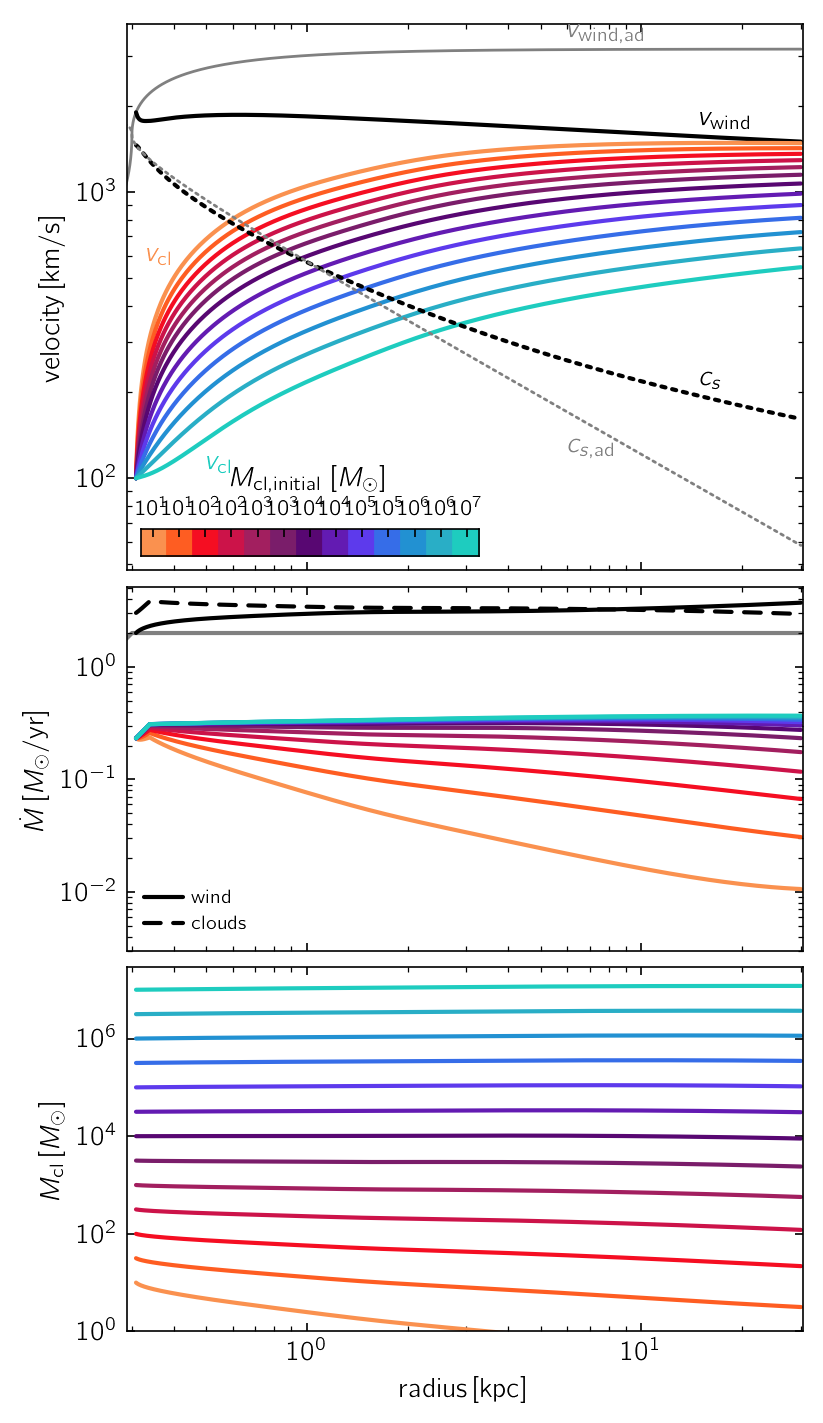

In [29]:
SFR = 20 * Msun/yr
eta_M              = 0.1
eta_M_cold_tot     = 0.2

### METALLICITY
Z_solar = 0.02

# feedback and SF props
E_SN  = 1e51
mstar = 100*Msun
M_cloud_min = 1e-2*Msun

## model choices
CoolingAreaChiPower         =  0.5 
ColdTurbulenceChiPower      = -0.5 
TurbulentVelocityChiPower   =  0.0 
geometric_factor            = 1.0
Mdot_coefficient            = 1.0/3.0
Cooling_Factor              = 1.0
drag_coeff                  = 0.5
f_turb0                     = 10**-1.0
v_circ0                     = 150e5 # gravitational potential assuming isothermal potential

r0                 = 300*pc
Z_wind_initial     = 2.0 * Z_solar
half_opening_angle = np.pi/2
Omwind             = 4*np.pi*(1.0 - np.cos(half_opening_angle))
eta_E              = 1

Mdot        = eta_M * SFR
Edot        = eta_E * (E_SN/mstar) * SFR

# properties at r0 if no clouds + gravity
epsilon     = 1e-5
Mach0       = 1.0 + epsilon
v0          = np.sqrt(Edot/Mdot)*(1/((gamma-1)*Mach0) + 1/2.)**(-1/2.)
rho0        = Mdot/(Omwind*r0**2 * v0)
P0          = rho0*v0**2 / Mach0**2 / gamma
rhoZ0       = rho0 * Z_wind_initial
print( "v_wind = %.1e km/s  n_wind = %.1e cm^-3  P_wind = %.1e kb K cm^-3" %(v0/1e5, rho0/(mu*mp), P0/kb))

Edot_per_Vol = Edot / (4/3. * np.pi * r0**3) # source terms from SN
Mdot_per_Vol = Mdot / (4/3. * np.pi * r0**3) # source terms from SN

r_init = 100*pc

dv_dr0, drho_dr0, dP_dr0 = Hot_Wind_Evo(r0, np.r_[v0, rho0, P0])

dlogvdlogr   = dv_dr0 * r0/v0
dlogrhodlogr = drho_dr0 * r0/rho0
dlogPdlogr   = dP_dr0 * r0/P0
dlogr0       = 1e-8

v0_sub   = 10**(np.log10(v0) - dlogvdlogr * dlogr0)
rho0_sub = 10**(np.log10(rho0) - dlogrhodlogr * dlogr0)
P0_sub   = 10**(np.log10(P0) - dlogPdlogr * dlogr0)

sol = solve_ivp(Hot_Wind_Evo, [10**(np.log10(r0)-dlogr0),r_init], np.r_[v0_sub, rho0_sub, P0_sub], 
    events=[supersonic], 
    dense_output=True,
    rtol=1e-12, atol=[1e-3, 1e-7*mp, 1e-2*kb])

r_init    = sol.t[-1]
v_init    = sol.y[0][-1]
rho_init  = sol.y[1][-1]
P_init    = sol.y[2][-1]
rhoZ_init = rho_init * Z_wind_initial

v0_sup   = 10**(np.log10(v0) + dlogvdlogr * dlogr0)
rho0_sup = 10**(np.log10(rho0) + dlogrhodlogr * dlogr0)
P0_sup   = 10**(np.log10(P0) + dlogPdlogr * dlogr0)

sol_sup = solve_ivp(Hot_Wind_Evo, [10**(np.log10(r0)+dlogr0),10**2*r0], np.r_[v0_sup, rho0_sup, P0_sup], 
    events=[subsonic], 
    dense_output=True,
    rtol=1e-12, atol=[1e-3, 1e-7*mp, 1e-2*kb])

r_hot_only         = np.append(sol.t[::-1], sol_sup.t)
v_wind_hot_only    = np.append(sol.y[0][::-1], sol_sup.y[0])
rho_wind_hot_only  = np.append(sol.y[1][::-1], sol_sup.y[1])
P_wind_hot_only    = np.append(sol.y[2][::-1], sol_sup.y[2])

Mdot_wind_hot_only      = Omwind*r_hot_only**2 * rho_wind_hot_only * v_wind_hot_only/(Msun/yr)
cs_wind_hot_only        = np.sqrt(gamma * P_wind_hot_only / rho_wind_hot_only)
T_wind_hot_only         = P_wind_hot_only/kb / (rho_wind_hot_only/(mu*mp))
K_wind_hot_only         = (P_wind_hot_only/kb) / (rho_wind_hot_only/(mu*mp))**gamma
Pdot_wind_hot_only      = Omwind * r_hot_only**2 * rho_wind_hot_only * v_wind_hot_only**2/(1e5*Msun/yr)
Pdot_wind_hot_only_P    = Omwind * r_hot_only**2 * (rho_wind_hot_only * v_wind_hot_only**2 + P_wind_hot_only)/(1e5*Msun/yr)
Edot_wind_hot_only      = Omwind * r_hot_only**2 * rho_wind_hot_only * v_wind_hot_only * (0.5 * v_wind_hot_only**2 + 1.5 * cs_wind_hot_only**2)/(1e5**2*Msun/yr)

# set up the cloud population
min_log_cloud_mass = 1
max_log_cloud_mass = 7
N_cloud_species = 13
alpha_cloud = 2
M_cloud0, eta_M_cold, Mdot_cold0, Ndot_cloud0 = setup_cloud_powerlaw_distribution(min_log_cloud_mass, max_log_cloud_mass, N_cloud_species, alpha_cloud, eta_M_cold_tot, SFR)
v_cloud0 = 100*km/s * np.ones_like(M_cloud0)
Z_cloud0 = 0.3 * Z_solar * np.ones_like(M_cloud0)
T_cloud = 1e4
# set up the initial conditions
r_init = r0
v_init = v0


cold_cloud_injection_radial_power = 3
cold_cloud_injection_radial_extent = 1.13*r0
cloud_radial_offest = 3e-2
irstart     = np.argmin(np.abs(r_hot_only-r0*(1.0+cloud_radial_offest)))
r_init      = r_hot_only[irstart]
v_init      = v_wind_hot_only[irstart]
rho_init    = rho_wind_hot_only[irstart]
P_init      = P_wind_hot_only[irstart]

supersonic_initial_conditions = np.concatenate([[v_init, 
                                                rho_init, 
                                                P_init, 
                                                Z_wind_initial*rho_init], 
                                                M_cloud0, v_cloud0, Z_cloud0])
sol = solve_ivp(Wind_Evo, [r_init, 1e2*r0], supersonic_initial_conditions, 
                events=[supersonic,cloud_stop,cold_wind], 
                dense_output=True, rtol=1e-10)



r         = sol.t
v_wind    = sol.y[0]
rho_wind  = sol.y[1]
P_wind    = sol.y[2]
rhoZ_wind = sol.y[3]
M_cloud   = sol.y[4:4+N_cloud_species]
v_cloud   = sol.y[4+N_cloud_species:4+2*N_cloud_species]
Z_cloud   = sol.y[-N_cloud_species:]

Z_wind = rhoZ_wind/rho_wind
K_wind = (P_wind/kb)/(rho_wind/(mu*mp))**gamma
T_wind = (P_wind/kb / (rho_wind/(mu*mp)))

cloud_Mdots  = (np.outer(Ndot_cloud0, np.where(r<cold_cloud_injection_radial_extent, (r/cold_cloud_injection_radial_extent)**cold_cloud_injection_radial_power, 1.0)) * M_cloud / (Msun/yr))
Mdot_wind    = Omwind * r**2 * rho_wind * v_wind/(Msun/yr)
cs_wind      = np.sqrt(gamma * P_wind / rho_wind)
T_wind       = P_wind/kb/(rho_wind/(mu*mp))
K_wind       = (P_wind/kb) / (rho_wind/(mu*mp))**gamma

Pdot_wind    = Omwind * r**2 * rho_wind * v_wind**2/(1e5*Msun/yr)
Pdot_wind_P  = Omwind * r**2 * (rho_wind * v_wind**2 + P_wind)/(1e5*Msun/yr)
cloud_Pdots  = (np.outer(Ndot_cloud0, np.where(r<cold_cloud_injection_radial_extent, (r/cold_cloud_injection_radial_extent)**cold_cloud_injection_radial_power, 1.0)) * M_cloud * v_cloud / (1e5 * Msun/yr))

Edot_wind    = Omwind * r**2 * rho_wind * v_wind * (0.5 * v_wind**2 + 1.5 * cs_wind**2)/(1e5**2*Msun/yr)
cloud_Edots  = (np.outer(Ndot_cloud0, np.where(r<cold_cloud_injection_radial_extent, (r/cold_cloud_injection_radial_extent)**cold_cloud_injection_radial_power, 1.0)) * M_cloud * (0.5 * v_cloud**2 + 2.5 * kb * T_cloud/(mu*mp)) / (1e5**2 * Msun/yr))



cloud_colors = cmr.take_cmap_colors('cmr.guppy', N_cloud_species, cmap_range=(0.0, 1.0), return_fmt='hex')



fig = plt.figure(constrained_layout=True)
gs = fig.add_gridspec(7, 1)
ax1 = fig.add_subplot(gs[:3,0])
ax3 = fig.add_subplot(gs[3:5,0])
ax2 = fig.add_subplot(gs[5:,0])

ax1.plot(r/kpc, v_wind/(km/s), label=r'$v_r$', color='k')
for i in range(N_cloud_species):
    ax1.plot(np.ma.masked_where(M_cloud[i] < 1.1 * M_cloud_min,r/kpc), np.ma.masked_where(M_cloud[i] < 1.1 * M_cloud_min,v_cloud[i]/(km/s)), color=cloud_colors[i])
ax1.plot(r/kpc, (gamma*P_wind/rho_wind)**0.5/(km/s), ls=':', label=r'$c_s$', color='k')
ax1.plot(r_hot_only/kpc, v_wind_hot_only/(km/s), color='grey', label=r'${\rm adiabatic}$', zorder=0,lw=1)
ax1.plot(r_hot_only/kpc, (gamma*P_wind_hot_only/rho_wind_hot_only)**0.5/(km/s), color='grey', ls=':',lw=1)
ax1.set_ylabel(r'${\rm velocity} \, [{\rm km/s}]$')
# ax1.legend(loc='best',fontsize=7)
ax1.set_xlim((2.9e-1, 30.5))
ax1.set_yscale('log')
ax1.set_xscale('log')

i_r10 = np.argmin(np.abs(r/kpc - 15))
ax1.text(r[i_r10]/kpc, v_wind[i_r10]/(km/s)*1.05, r'$v_{\rm wind}$', color='k', ha='left', va='bottom')
ax1.text(r[i_r10]/kpc, ((gamma*P_wind/rho_wind)**0.5/(km/s))[i_r10]*1.05, r'$c_s$', color='k', ha='left', va='bottom')

i_r10 = np.argmin(np.abs(r_hot_only/kpc - 6))
ax1.text(r_hot_only[i_r10]/kpc, v_wind_hot_only[i_r10]/(km/s)*1.05, r'$v_{\rm wind,ad}$', color='grey', ha='left', va='bottom')
ax1.text(r_hot_only[i_r10]/kpc, ((gamma*P_wind_hot_only/rho_wind_hot_only)**0.5/(km/s))[i_r10]/1.2, r'$c_{s, {\rm ad}}$', color='grey', ha='left', va='top')


i_r04 = np.argmin(np.abs(r/kpc - 0.4))
ax1.text(r[i_r04]/kpc, v_cloud[0][i_r04]/(km/s)*1.1, r'$v_{\rm cl}$', color=cloud_colors[0], ha='right', va='bottom')
i_r1 = np.argmin(np.abs(r/kpc - 0.5))
ax1.text(r[i_r1]/kpc, v_cloud[-1][i_r1]/(km/s)/1.1, r'$v_{\rm cl}$', color=cloud_colors[-1], ha='left', va='top')


cax = inset_axes(ax1,width="50%",  # width = 50% of parent_bbox width
                    height="5%",  # height : 5%
                    loc='lower left')

dlog_Mcloud0 = (max_log_cloud_mass-min_log_cloud_mass)/N_cloud_species
cloud_mass_edges = np.linspace(min_log_cloud_mass-dlog_Mcloud0*0.5, max_log_cloud_mass+dlog_Mcloud0*0.5, N_cloud_species+1)
for i in range(N_cloud_species):
    cax.fill_betweenx([0,1], cloud_mass_edges[i], cloud_mass_edges[i+1], color = cloud_colors[i])
cax.set_xlabel(r'$M_{\rm cl, initial} \; [M_\odot]$',fontsize=10, labelpad=5)    
cax.xaxis.set_label_position('top') 
cax.xaxis.tick_top()
cax.set_xticks(np.linspace(min_log_cloud_mass, max_log_cloud_mass, N_cloud_species))
cax.set_xticklabels(np.array([ r'$10^{%i}$' %m for m in  np.linspace(min_log_cloud_mass, max_log_cloud_mass, N_cloud_species)]), fontsize=8)
cax.set_yticks([])
cax.minorticks_off()
cax.set_xlim((cloud_mass_edges[0],cloud_mass_edges[-1]))
cax.set_ylim((0.1,0.9))


for i in range(N_cloud_species):
    ax2.loglog(np.ma.masked_where(M_cloud[i] < 1.1 * M_cloud_min,r/kpc), np.ma.masked_where(M_cloud[i] < 1.1 * M_cloud_min,M_cloud[i]/Msun), color=cloud_colors[i])
ax2.set_ylabel(r'$M_{\rm cl} \, [M_\odot]$')    
# ax2.set_yticks([1e0,1e1,1e2,1e3,1e4,1e5])
ax2.set_ylim(bottom=1)
ax2.set_xlim((2.9e-1, 30.5))

ax3.plot(r/kpc, Omwind*r**2 * rho_wind*v_wind / (Msun/yr), label=r"${\rm wind}$", color='k')
ax3.plot(r_hot_only/kpc, Omwind*r_hot_only**2 * rho_wind_hot_only*v_wind_hot_only / (Msun/yr), color='grey', zorder=0)
for i in range(N_cloud_species):
    ax3.plot( np.ma.masked_where(M_cloud[i] < 1.1 * M_cloud_min, r/kpc), np.ma.masked_where(M_cloud[i] < 1.1 * M_cloud_min,cloud_Mdots[i]), color=cloud_colors[i])
ax3.plot(r/kpc, np.sum(cloud_Mdots, axis=0), dashes=[4,3], label=r"${\rm clouds}$" , color='k')
ax3.set_ylabel(r'$\dot{M} \, [M_\odot / {\rm yr}]$')    
ax3.legend(loc='best',fontsize=7, frameon=False)
ax3.loglog()
ax3.set_yscale('log')
ax3.set_xscale('log')
ax3.set_xlim((2.9e-1, 30.5))
ax3.set_ylim(bottom=3e-3)

ax1.set_xticklabels([])
# ax2.set_xticklabels([])
# ax3.set_xlabel(r'${\rm radius} \, [{\rm kpc}]$')
ax3.set_xticklabels([])
ax2.set_xlabel(r'${\rm radius} \, [{\rm kpc}]$')

fig.set_size_inches(4,7)
plt.show()